# Un agujero negro de 6.000 millones de soles — y lo vemos cuando el universo era joven

Pesa casi lo mismo que el agujero negro gigante de M87, el primero que la humanidad fotografió. Pero este está tan lejos que su luz salió hace unos 10.300 millones de años, cuando el universo tenía apenas un cuarto de su edad. ¿Cómo se pesa un agujero negro a esa distancia?

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** *A stellar dynamical mass measurement of an inactive black hole at redshift 2* — Newman et al. (2026), **Science**.
**DOI:** [10.1126/science.adx5816](https://doi.org/10.1126/science.adx5816)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-06-04-masa-agujero-negro-redshift-2/notebook.ipynb)

> Video: [Ver en YouTube](https://youtube.com/shorts/vdCKhEI9ZuM)

## ¿Qué midieron, y por qué es tan difícil?

Para pesar un agujero negro no lo miras a él —es negro—, miras cómo se mueven las estrellas a su alrededor. Cuanto más masa hay en el centro, más rápido orbitan las estrellas cercanas. El problema: a esta galaxia, **MRG-M0138**, la vemos a un *redshift* de 1,95 (el título redondea a "2"), tan lejos que distinguir las estrellas del mismísimo centro debería ser imposible.

Dos golpes de suerte lo permitieron. Primero, una galaxia en primer plano actúa como **lente gravitacional** y amplía la imagen, dándonos resolución suficiente para asomarnos al corazón de MRG-M0138. Segundo, su agujero negro está **inactivo** (no es un núcleo brillante que tape todo), así que la luz de las estrellas llega limpia. Con el telescopio espacial **James Webb** y su espectroscopía de campo integral, el equipo mapeó la velocidad de las estrellas región por región.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
M_BH_PAPER   = 6.0e9     # Masa del agujero negro medida por el paper (masas solares)
M87_BH       = 6.5e9     # M87*, el agujero negro fotografiado por el EHT (masas solares)
SGRA_BH      = 4.0e6     # Sgr A*, el del centro de nuestra galaxia (masas solares)
R_CORTE_PC   = 100       # Frontera centro/afueras para comparar velocidades (parsecs)
FUENTE       = 'Fuente: Newman et al. (2026), Science | Datos: Zenodo 10.5281/zenodo.16767130'
COLOR_DATOS       = '#2563EB'   # Azul CaM
COLOR_ALERTA      = '#DC2626'   # Rojo
COLOR_REFERENCIA  = '#D97706'   # Ámbar
COLOR_SECUNDARIO  = '#059669'   # Emerald
COLOR_CONTEXTO    = '#BBBBBB'   # Gris

import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Estilo CaM (local -> /tmp -> GitHub raw)
BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)
os.makedirs('figuras', exist_ok=True)

# Carga de datos
kin = pd.read_csv('datos/kinematics_bins.csv')
rad = pd.read_csv('datos/perfil_radial.csv')
mge = pd.read_csv('datos/perfil_mge.csv')

# Bins válidos (9 enmascarados como NaN)
val = kin.dropna(subset=['v_rms']).copy()

# Escala física derivada de los propios datos (pc por arcsec en el plano fuente)
escala_pc_arcsec = (val['r_pc'] / val['r_src']).median()
val['x_pc'] = val['x_src'] * escala_pc_arcsec
val['y_pc'] = val['y_src'] * escala_pc_arcsec

print(f"Bins totales: {len(kin)} | válidos: {len(val)} | enmascarados: {kin['v_rms'].isna().sum()}")
print(f"Escala lente: {escala_pc_arcsec/1000:.2f} kpc/arcsec")
print(f"V_rms: mín {val.v_rms.min():.0f}  máx {val.v_rms.max():.0f}  "
      f"mediana {val.v_rms.median():.0f} km/s  (IQR {val.v_rms.quantile(.25):.0f}-{val.v_rms.quantile(.75):.0f})")
print(f"Dispersión estelar sigma: {val.sigma.min():.0f} - {val.sigma.max():.0f} km/s")
print(f"Bin más interno: {val.r_pc.min():.0f} pc")

Bins totales: 219 | válidos: 210 | enmascarados: 9
Escala lente: 8.39 kpc/arcsec
V_rms: mín 246  máx 470  mediana 391 km/s  (IQR 350-421)
Dispersión estelar sigma: 195 - 467 km/s
Bin más interno: 51 pc


## El mapa de velocidades

Aquí está.

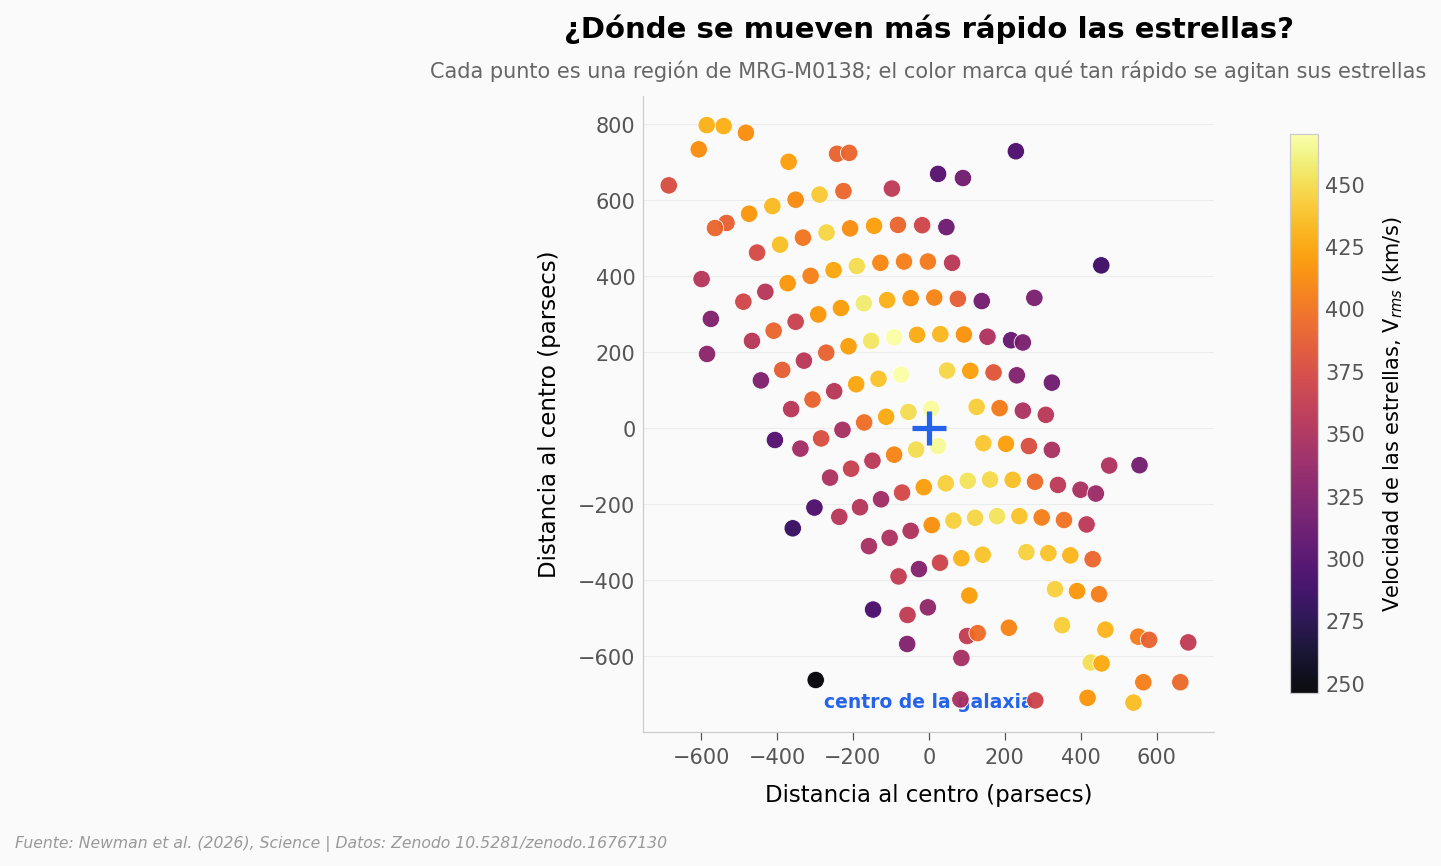

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

# Recortamos a la región central donde está la acción (la mayoría de los bins)
lim = 800  # parsecs
m = (val.x_pc.abs() < lim) & (val.y_pc.abs() < lim)
sc = ax.scatter(val.x_pc[m], val.y_pc[m], c=val.v_rms[m], cmap='inferno',
                s=70, alpha=0.95, edgecolors='white', linewidths=0.4, zorder=5)
ax.scatter(0, 0, marker='+', s=260, color=COLOR_DATOS, linewidths=2.5, zorder=6)
ax.text(0, -lim*0.92, 'centro de la galaxia', fontsize=9, ha='center',
        color=COLOR_DATOS, fontweight='bold')

cbar = plt.colorbar(sc, ax=ax, shrink=0.88)
cbar.set_label('Velocidad de las estrellas, V$_{rms}$ (km/s)', fontsize=10)

ax.set_xlabel('Distancia al centro (parsecs)', fontsize=11)
ax.set_ylabel('Distancia al centro (parsecs)', fontsize=11)
ax.set_aspect('equal')
ax.set_title('¿Dónde se mueven más rápido las estrellas?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Cada punto es una región de MRG-M0138; el color marca qué tan rápido se agitan sus estrellas',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/mapa_velocidades.png', dpi=200, bbox_inches='tight')
plt.show()

El centro arde. Justo donde marcamos la cruz, las estrellas se agitan a más de 450 km/s, mientras que en las afueras se calman hacia unos 380 km/s. Esa concentración de movimiento rápido en un punto diminuto es exactamente lo que delata una gran masa escondida: algo está tirando de las estrellas con mucha fuerza ahí en medio.

No es un efecto de la rotación de la galaxia. La cantidad que graficamos, V$_{rms}$, combina la rotación y la agitación al azar (V$_{rms} = \sqrt{V^2 + \sigma^2}$), así que no importa si las estrellas giran ordenadamente o se mueven en desorden: lo que mide es la energía total de su movimiento.

## ¿Cuánto sube la velocidad hacia el centro?

El mapa lo insinúa; el perfil radial lo cuantifica. Promediamos la velocidad de las estrellas en anillos cada vez más lejanos del centro y vemos cómo cambia.

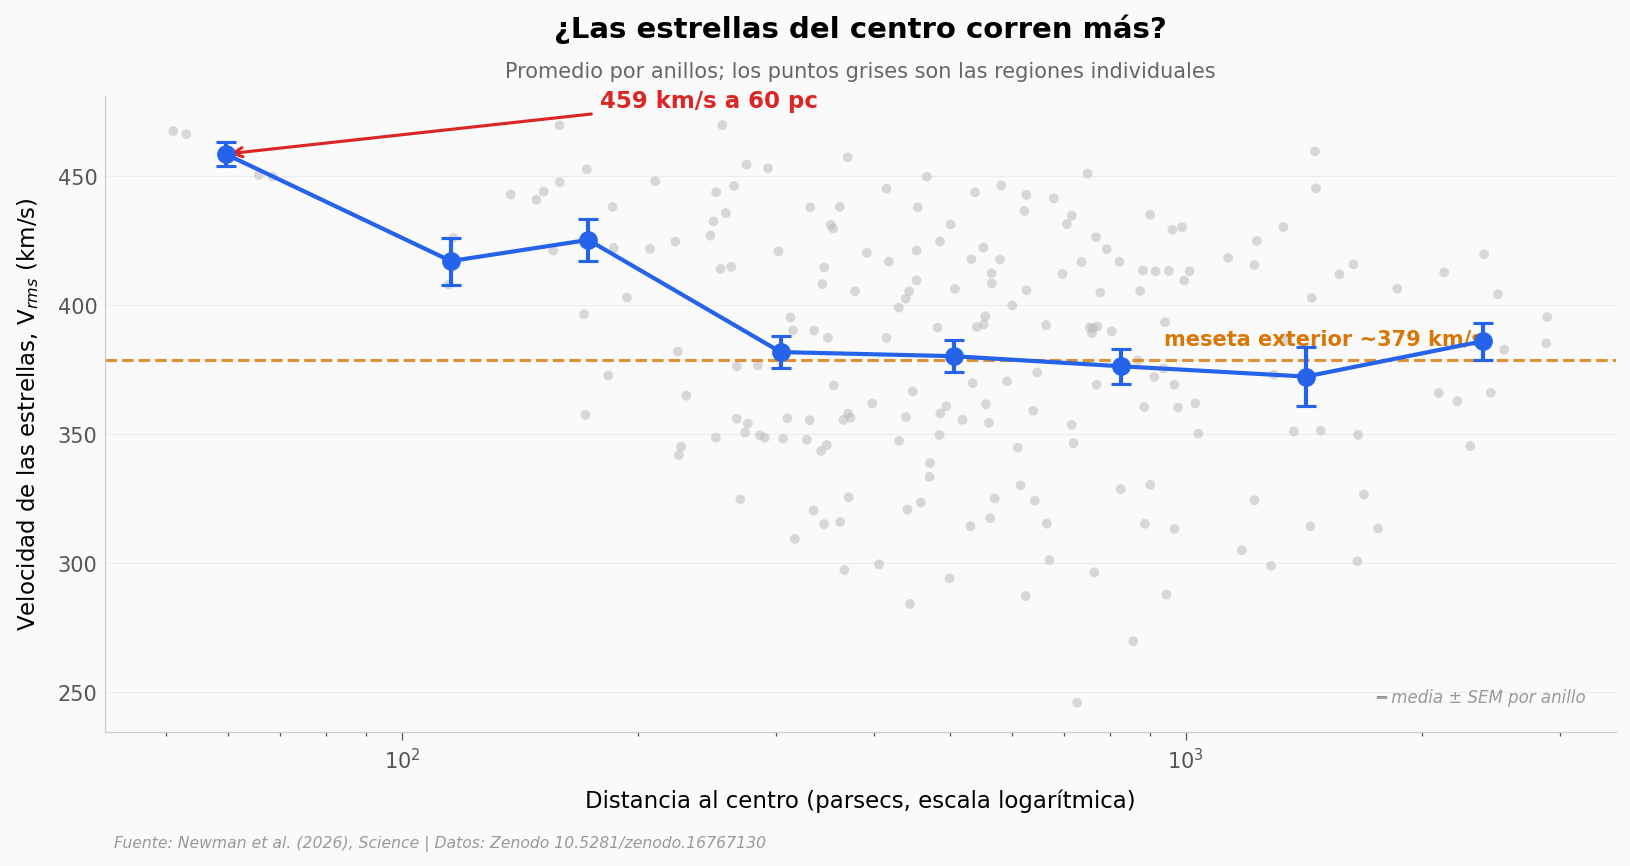

Anillo interior (60 pc): 459 km/s
Meseta exterior: 379 km/s
Subida central: +21%


In [3]:
fig, ax = plt.subplots(figsize=(13, 5.5))

# Bins individuales de fondo (contexto)
ax.scatter(val.r_pc, val.v_rms, color=COLOR_CONTEXTO, s=22, alpha=0.55,
           edgecolors='none', zorder=2)
# Perfil promediado en anillos, con barras de error (media +/- SEM)
ax.errorbar(rad.r_pc_mean, rad.v_rms_mean, yerr=rad.v_rms_sem,
            fmt='o-', color=COLOR_DATOS, markersize=8, linewidth=2,
            capsize=5, capthick=1.5, zorder=5)

# Meseta exterior como referencia
meseta = rad.v_rms_mean.iloc[-4:].mean()
ax.axhline(meseta, color=COLOR_REFERENCIA, linewidth=1.5, linestyle='--', alpha=0.8)
ax.text(2400, meseta + 6, f'meseta exterior ~{meseta:.0f} km/s',
        fontsize=10, color=COLOR_REFERENCIA, fontweight='bold', ha='right')

# Anotar el anillo más interno
r0, v0 = rad.r_pc_mean.iloc[0], rad.v_rms_mean.iloc[0]
ax.annotate(f'{v0:.0f} km/s a {r0:.0f} pc',
            xy=(r0, v0), xytext=(r0*3, v0 + 18),
            fontsize=11, fontweight='bold', color=COLOR_ALERTA,
            arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.5))

ax.set_xscale('log')
ax.set_xlabel('Distancia al centro (parsecs, escala logarítmica)', fontsize=11)
ax.set_ylabel('Velocidad de las estrellas, V$_{rms}$ (km/s)', fontsize=11)
ax.set_title('¿Las estrellas del centro corren más?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Promedio por anillos; los puntos grises son las regiones individuales',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.text(0.98, 0.04, '━ media ± SEM por anillo', transform=ax.transAxes,
        fontsize=8, color='#999999', ha='right', va='bottom', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/perfil_radial.png', dpi=200, bbox_inches='tight')
plt.show()

subida = 100 * (v0 / meseta - 1)
print(f"Anillo interior ({r0:.0f} pc): {v0:.0f} km/s")
print(f"Meseta exterior: {meseta:.0f} km/s")
print(f"Subida central: +{subida:.0f}%")

## ¿Y la galaxia? ¿Está tan apretada como parece?

Un centro que tira tan fuerte suele venir con estrellas muy concentradas. El equipo descompuso la luz de la galaxia (en el filtro infrarrojo F200W del Webb) en una suma de componentes para reconstruir cuánta luz hay a cada distancia del centro. Sumémoslas y veamos el perfil.

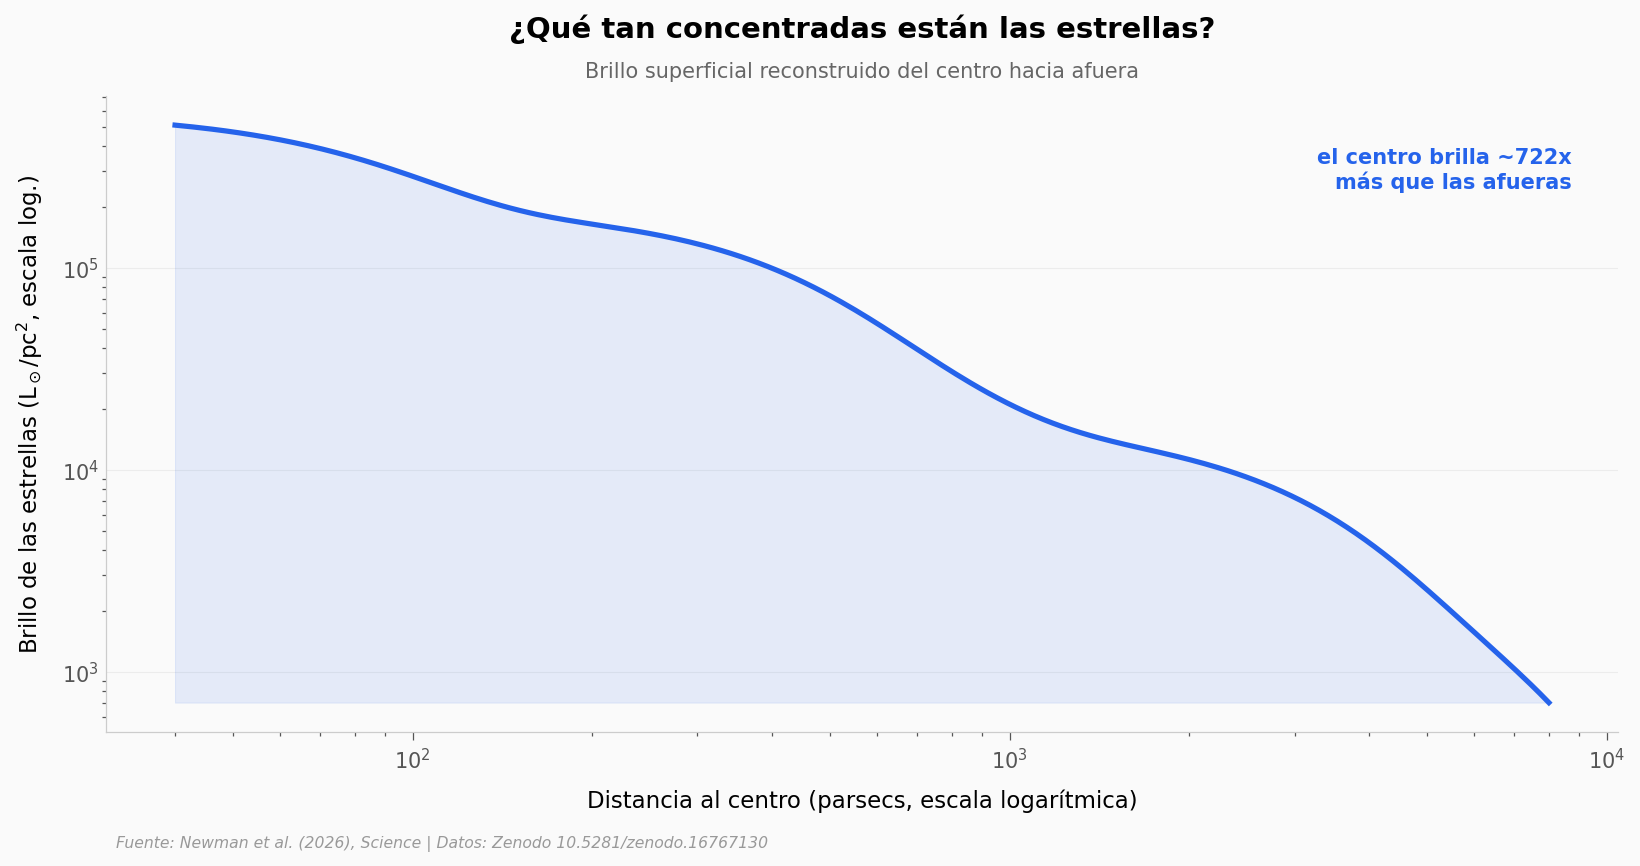

Brillo central / brillo a 8 kpc: 722x


In [4]:
fig, ax = plt.subplots(figsize=(13, 5.5))

luz = mge[mge.component == 'luminosidad_F200W']
r = np.logspace(np.log10(40), np.log10(8000), 300)  # parsecs
# Suma de gaussianas: brillo superficial reconstruido a cada radio
sb = np.zeros_like(r)
for _, g in luz.iterrows():
    sb += g.peak_SB_Lsun_pc2 * np.exp(-0.5 * (r / g.sigma_pc) ** 2)

ax.plot(r, sb, color=COLOR_DATOS, linewidth=2.5, zorder=5)
ax.fill_between(r, sb, sb.min(), color=COLOR_DATOS, alpha=0.10, zorder=2)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Distancia al centro (parsecs, escala logarítmica)', fontsize=11)
ax.set_ylabel('Brillo de las estrellas (L$_\\odot$/pc$^2$, escala log.)', fontsize=11)
ax.set_title('¿Qué tan concentradas están las estrellas?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Brillo superficial reconstruido del centro hacia afuera',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

caida = sb[0] / sb[-1]
ax.text(0.97, 0.92, f'el centro brilla ~{caida:,.0f}x\nmás que las afueras'.replace(',', '.'),
        transform=ax.transAxes, fontsize=10, color=COLOR_DATOS,
        fontweight='bold', ha='right', va='top')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/perfil_brillo.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"Brillo central / brillo a 8 kpc: {caida:,.0f}x".replace(',', '.'))

## ¿Qué tan inusual es ese centro veloz?

Pongamos el pico de velocidad del centro contra todo el resto de la galaxia. Si el centro fuera "normal", su velocidad caería en medio del montón.

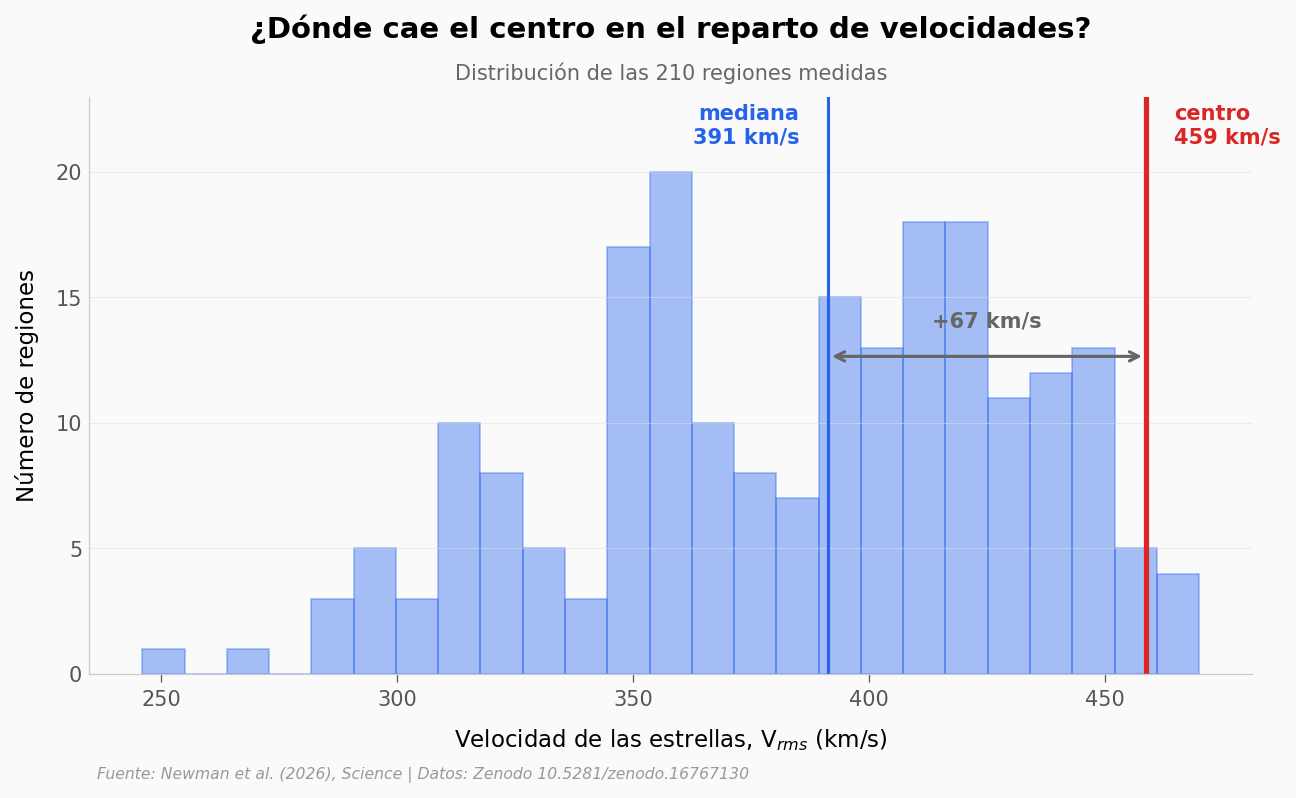

El anillo central (459 km/s) supera al 98% de las regiones


In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

n, bins, patches = ax.hist(val.v_rms, bins=25, color=COLOR_DATOS, alpha=0.4,
                           edgecolor=COLOR_DATOS, linewidth=0.8)
y_max = n.max() * 1.15
ax.set_ylim(0, y_max)

mediana = val.v_rms.median()
v_centro = rad.v_rms_mean.iloc[0]   # anillo más interno
ax.axvline(mediana, color=COLOR_DATOS, linewidth=1.5)
ax.text(mediana - 6, y_max*0.92, f'mediana\n{mediana:.0f} km/s',
        fontsize=10, color=COLOR_DATOS, ha='right', fontweight='bold')
ax.axvline(v_centro, color=COLOR_ALERTA, linewidth=2.5)
ax.text(v_centro + 6, y_max*0.92, f'centro\n{v_centro:.0f} km/s',
        fontsize=10, color=COLOR_ALERTA, ha='left', fontweight='bold')

ax.annotate('', xy=(v_centro, y_max*0.55), xytext=(mediana, y_max*0.55),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((mediana + v_centro)/2, y_max*0.60, f'+{v_centro - mediana:.0f} km/s',
        fontsize=10, color='#666666', ha='center', fontweight='bold')

ax.set_xlabel('Velocidad de las estrellas, V$_{rms}$ (km/s)', fontsize=11)
ax.set_ylabel('Número de regiones', fontsize=11)
ax.set_title('¿Dónde cae el centro en el reparto de velocidades?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Distribución de las 210 regiones medidas',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/histograma_velocidades.png', dpi=200, bbox_inches='tight')
plt.show()

pct = 100 * (val.v_rms < v_centro).mean()
print(f"El anillo central ({v_centro:.0f} km/s) supera al {pct:.0f}% de las regiones")

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| Las estrellas del centro se mueven más rápido | ✅ | El anillo más interno (~60 pc) llega a ~459 km/s frente a una meseta de ~380 km/s en las afueras: una subida de ~21%. |
| La galaxia tiene un núcleo estelar muy concentrado | ✅ | El brillo superficial cae unas 700 veces del centro hacia afuera —casi tres órdenes de magnitud— (reconstrucción de la descomposición de luz F200W). |
| El agujero negro pesa unos 6.000 millones de soles | ⚠️ | Es el valor del paper (6,0 ⁺²·¹₋₁·₇ × 10⁹ masas solares), obtenido con modelos dinámicos que corren en un clúster de cómputo y que **no reproducimos aquí**. Este notebook muestra la *evidencia observable* (el campo de velocidades), no recalcula la masa. |
| El agujero negro es sobremasivo para el tamaño de su bulbo | ⚠️ | Afirmación cualitativa del paper. Es consistente con la relación masa–dispersión (M–σ), pero **no** con la masa del bulbo. No la recalculamos: una estimación cruda contradiría al paper porque omite el modelado completo. |

> **Limitaciones:** (1) La masa del agujero negro proviene de modelos dinámicos (el método JAM) que requieren un modelo de la lente gravitacional y corren en un clúster de cómputo; aquí solo reproducimos el observable que los restringe. (2) Es **una sola galaxia** medida con esta técnica a este *redshift*: no es una muestra estadística. (3) Las barras de error de cada anillo (±SEM) reflejan dispersión entre regiones, no la incertidumbre completa del modelado dinámico. (4) El radio de la "esfera de influencia" del agujero negro es de orden ~unos cientos de pc; no lo medimos con precisión aquí.

## Ahora tú

1. **¿Y si mueves la frontera centro/afueras?** En la celda de abajo cambia `R_CORTE_PC` (prueba 60, 150, 300) y mira cómo cambia el contraste de velocidad entre el corazón y el resto. ¿A partir de qué radio se desvanece el exceso?

2. **¿Cuántas estrellas alcanzan el récord?** ¿Qué fracción de regiones supera los 450 km/s? Pista: `(val.v_rms > 450).mean()`.

3. **¿Rotación o desorden?** Compara la rotación (`val.V`) con la agitación al azar (`val.sigma`) en el centro frente a las afueras. ¿El centro gira más, o se agita más? Pista: filtra por `val.r_pc < R_CORTE_PC`.

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Compara la velocidad media de las estrellas dentro y fuera de un radio.
# Cambia R_CORTE_PC (definido arriba) y vuelve a ejecutar.

dentro = val[val.r_pc < R_CORTE_PC]
fuera  = val[val.r_pc >= R_CORTE_PC]

v_dentro = np.average(dentro.v_rms, weights=dentro.n_spaxels)
v_fuera  = np.average(fuera.v_rms,  weights=fuera.n_spaxels)

print(f"Radio de corte: {R_CORTE_PC} pc")
print(f"  Dentro ({len(dentro)} regiones): {v_dentro:.0f} km/s")
print(f"  Fuera  ({len(fuera)} regiones): {v_fuera:.0f} km/s")
print(f"  Contraste centro/afueras: +{100*(v_dentro/v_fuera - 1):.0f}%")

Radio de corte: 100 pc
  Dentro (4 regiones): 459 km/s
  Fuera  (206 regiones): 358 km/s
  Contraste centro/afueras: +28%


---

## Fuentes

**Paper**: [A stellar dynamical mass measurement of an inactive black hole at redshift 2](https://doi.org/10.1126/science.adx5816)  
*Science, 2026-06-04*

**Datos**: [Code and data used to measure the black hole mass in MRG-M0138 (Newman 2026)](https://doi.org/10.5281/zenodo.16767130)

**Referencias citadas**: [Observaciones JWST de MRG-M0138 (MAST)](https://doi.org/10.17909/ryaj-k740)

*9 afirmaciones del notebook verificadas contra estas fuentes*

---

*Notebook reproducible de [Ciencia a Mordiscos](https://cienciaamordiscos.com). Código y datos: [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab). Datos originales bajo licencia abierta de los autores (Zenodo).*